## Importing libraries

In [1]:
import os
import h5py
import numpy as np
import json
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Image, display, clear_output
from sklearn.metrics import classification_report, confusion_matrix

from keras import optimizers
from keras.applications.vgg16 import VGG16
from keras.models import Sequential, load_model, Model
from keras.layers import Conv2D, MaxPooling2D, ZeroPadding2D, Activation, Dropout, Flatten, Dense, Input
from keras.regularizers import l2, l1
from tensorflow.keras.utils import to_categorical
from keras.preprocessing.image import  array_to_img, img_to_array, load_img
from keras.callbacks import ModelCheckpoint, History
from keras import backend as K
from tensorflow.keras.utils import get_file
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout, Input
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import SGD
import json

%matplotlib inline
sns.set_style('whitegrid')

In [2]:
def print_best_model_results(model_hist):
    best_epoch = np.argmax(model_hist['val_accuracy'])
    print('epoch:', best_epoch+1, \
    ', val_accuracy:', model_hist['val_accuracy'][best_epoch], \
    ', val_loss:', model_hist['val_loss'][best_epoch])

In [3]:
def plot_metrics(hist, stop=50):
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,4))
                            
    axes = axes.flatten()

    axes[0].plot(range(stop), hist['accuracy'], label='Training', color='#FF533D')
    axes[0].plot(range(stop), hist['val_accuracy'], label='Validation', color='#03507E')
    axes[0].set_title('Accuracy')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].legend(loc='lower right')
                             
    axes[1].plot(range(stop), hist['loss'], label='Training', color='#FF533D')
    axes[1].plot(range(stop), hist['val_loss'], label='Validation', color='#03507E')
    axes[1].set_title('Loss')
    axes[1].set_ylabel('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].legend(loc='upper right')
                             
    plt.tight_layout();
    
    print("Best Model:") 
    print_best_model_results(hist)

In [53]:
def evaluate_categorical_model(model, directory, labels):
    datagen = ImageDataGenerator(rescale=1./255)  

    generator = datagen.flow_from_directory(directory,
                                target_size=(img_height, img_width),
                                batch_size=8,
                                class_mode='categorical',
                                shuffle=False)
    
    predictions = model.predict(generator, len(labels))
    pred_labels = np.argmax(predictions, axis=1)
    
    print ('')
    print (classification_report(validation_labels, pred_labels))
    print ('')
    cm = confusion_matrix(validation_labels, pred_labels)
    sns.heatmap(cm, annot=True);

In [5]:
def save_bottleneck_features():
    datagen = ImageDataGenerator(rescale=1./255)
    
    model = VGG16(include_top=False, weights='imagenet')
    
    generator = datagen.flow_from_directory(train_data_dir, target_size=(img_width, img_height), batch_size=batch_size, class_mode=None, shuffle=False)
    bottleneck_features_train = model.predict(generator, nb_train_samples // batch_size)
    np.save(location+'/bottleneck_features_train.npy', bottleneck_features_train)
    
    generator = datagen.flow_from_directory(validation_data_dir, target_size=(img_width, img_height), batch_size=batch_size, class_mode=None, shuffle=False)
    bottleneck_features_validation = model.predict(generator, nb_validation_samples // batch_size)
    np.save(location+'/bottleneck_features_validation.npy', bottleneck_features_validation)

## Path of the models

In [10]:
location = 'data_2'
top_model_weights_path = location+'/top_model_weights.keras'
fine_tuned_model_path = location+'/ft_model.keras'
top_model_weights_path_l2 = location+'/top_model_weights_l2.keras'
model1 = location+'/bottleneck_fc_model.h5'

train_data_dir = location+'/training'
validation_data_dir = location+'/validation'
train_samples = [len(os.listdir(train_data_dir+'/'+i)) for i in sorted(os.listdir(train_data_dir))]
nb_train_samples = 979
validation_samples = [len(os.listdir(validation_data_dir+'/'+i)) for i in sorted(os.listdir(validation_data_dir))]
nb_validation_samples = 171

img_width, img_height = 256,256
epochs = 50
batch_size = 64

In [ ]:
save_bottleneck_features()

## model 1

In [7]:
def train_top_model():
    # Load bottleneck features
    train_data = np.load(location + '/bottleneck_features_train.npy')
    train_labels = np.array([0] * 419 + [1] * 288 + [2] * 272)  
    train_labels = to_categorical(train_labels, num_classes=3)  # Convert to one-hot encoding
    
    validation_data = np.load(location + '/bottleneck_features_validation.npy')
    validation_labels = np.array([0] * 73 + [1] * 50 + [2] * 48)
    validation_labels = to_categorical(validation_labels, num_classes=3)  # Convert to one-hot encoding
    
    # Define the top model
    model = Sequential()
    model.add(Flatten(input_shape=train_data.shape[1:]))
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(3, activation='softmax'))  # Updated for 3 classes
    
    # Compile the model
    model.compile(optimizer='adam', 
                  loss='categorical_crossentropy',  # Updated loss function
                  metrics=['accuracy'])
    
    # Define ModelCheckpoint to save the best model
    checkpoint = ModelCheckpoint(filepath=top_model_weights_path, 
                                 monitor='val_accuracy',  
                                 verbose=1, 
                                 save_best_only=True, 
                                 save_weights_only=False,  # Save the entire model
                                 mode='auto')
    
    # Fit the model
    fit = model.fit(train_data, 
                    train_labels, 
                    epochs=epochs, 
                    batch_size=batch_size, 
                    validation_data=(validation_data, validation_labels), 
                    callbacks=[checkpoint])
    
    # Save training history
    with open(location + '/top_history.json', 'w') as f:
        json.dump(fit.history, f)
    
    # Save the entire model manually
    model.save(location + '/top_model_final.h5')
    print("Model saved successfully.")
    
    return model, fit.history


In [8]:
d2_model1, d2_history1 = train_top_model()

Epoch 1/50


c:\Users\pbans\OneDrive\Desktop\CD2\.conda\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.3568 - loss: 6.1113
Epoch 1: val_accuracy improved from -inf to 0.47368, saving model to data_2/top_model_weights.keras
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.3573 - loss: 6.0345 - val_accuracy: 0.4737 - val_loss: 1.5489
Epoch 2/50
15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.4903 - loss: 1.4442
Epoch 2: val_accuracy improved from 0.47368 to 0.64327, saving model to data_2/top_model_weights.keras
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.4957 - loss: 1.4100 - val_accuracy: 0.6433 - val_loss: 0.8404
Epoch 3/50
15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.6498 - loss: 0.7900
Epoch 3: val_accuracy did not improve from 0.64327
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.6510 - loss: 0.7863 - val_accuracy: 0.6433 - val_loss: 0.8179
Epoch 4/50
15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7063 - loss: 0.6594
Epoch 4: val_accuracy improved from 0.64327 to 0.70760, saving model 

Model saved successfully.


Best Model:
epoch: 23 , val_accuracy: 0.7602339386940002 , val_loss: 0.8210432529449463


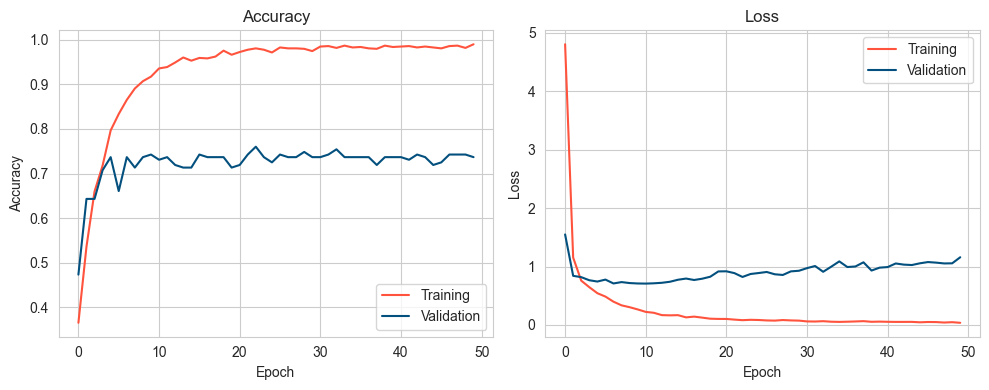

In [9]:
plot_metrics(d2_history1)

In [26]:
def train_top_model_l2():
    # Load bottleneck features
    train_data = np.load(location + '/bottleneck_features_train.npy')
    train_labels = np.array([0] * 419 + [1] * 288 + [2] * 272)  
    train_labels = to_categorical(train_labels, num_classes=3)  # Convert to one-hot encoding
    
    validation_data = np.load(location + '/bottleneck_features_validation.npy')
    validation_labels = np.array([0] * 73 + [1] * 50 + [2] * 48)
    validation_labels = to_categorical(validation_labels, num_classes=3)  # Convert to one-hot encoding
    
    # Define the top model
    model_l2 = Sequential()
    model_l2.add(Flatten(input_shape=train_data.shape[1:]))
    model_l2.add(Dense(256, activation='relu',kernel_regularizer=regularizers.l2(0.01)))
    model_l2.add(Dropout(0.5))
    model_l2.add(Dense(3, activation='softmax'))  # Updated for 3 classes
    
    # Compile the model
    model_l2.compile(optimizer='rmsprop', 
                  loss='categorical_crossentropy',  # Updated loss function
                  metrics=['accuracy'])
    
    # Define ModelCheckpoint to save the best model
    checkpoint = ModelCheckpoint(filepath=top_model_weights_path_l2, 
                                 monitor='val_accuracy',  
                                 verbose=1, 
                                 save_best_only=True, 
                                 save_weights_only=False,  # Save the entire model
                                 mode='auto')
    
    # Fit the model
    fit = model_l2.fit(train_data, 
                    train_labels, 
                    epochs=epochs, 
                    batch_size=batch_size, 
                    validation_data=(validation_data, validation_labels), 
                    callbacks=[checkpoint])
    
    # Save training history
    with open(location + '/top_history_l2.json', 'w') as f:
        json.dump(fit.history, f)
    
    # Save the entire model manually
    model_l2.save(location + '/top_model_final_l2.h5')
    print("Model saved successfully.")
    
    return model_l2, fit.history


In [27]:
from tensorflow.keras import regularizers

d2_model_l2, d2_history_l2 = train_top_model_l2()

Epoch 1/50
15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.3474 - loss: 18.5401
Epoch 1: val_accuracy improved from -inf to 0.42690, saving model to data_2/top_model_weights_l2.keras
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.3495 - loss: 17.7073 - val_accuracy: 0.4269 - val_loss: 3.1542
Epoch 2/50
15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.4334 - loss: 3.1026
Epoch 2: val_accuracy improved from 0.42690 to 0.50877, saving model to data_2/top_model_weights_l2.keras
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.4323 - loss: 3.0685 - val_accuracy: 0.5088 - val_loss: 2.0234
Epoch 3/50
15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.4484 - loss: 1.9222
Epoch 3: val_accuracy did not improve from 0.50877
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.4493 - loss: 1.9146 - val_accuracy: 0.3626 - val_loss: 1.5827
Epoch 4/50
15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.4432 - loss: 1.5338
Epoch 4: val_accuracy did not improve from 0.50877

Model saved successfully.


Best Model:
epoch: 32 , val_accuracy: 0.7309941649436951 , val_loss: 0.9234511256217957


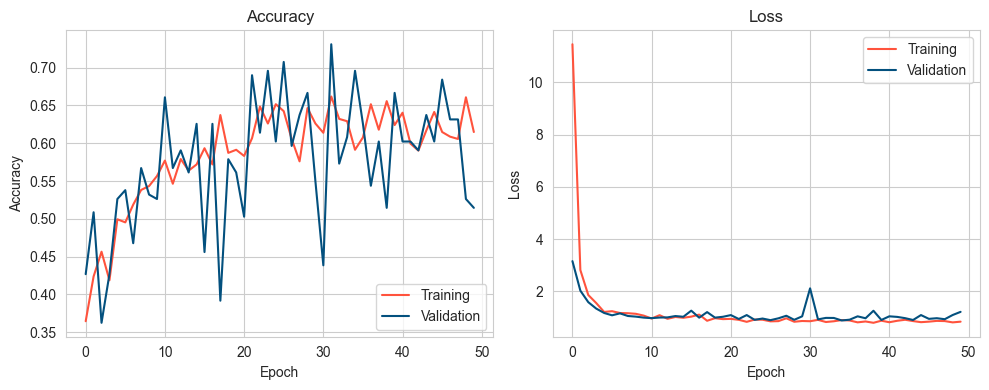

In [28]:
plot_metrics(d2_history_l2)

In [33]:
def finetune_binary_model():
    # Load base VGG16 model without the top layers
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=(256, 256, 3))
    print("Base model loaded.")
    
    # Add custom top model
    top_model = Sequential()
    top_model.add(Flatten(input_shape=base_model.output_shape[1:]))
    top_model.add(Dense(256, activation='relu'))
    top_model.add(Dropout(0.5))
    top_model.add(Dense(3, activation='softmax'))  # Binary classification output

    # Attach top model to base model
    model = Model(inputs=base_model.input, outputs=top_model(base_model.output))

    # Freeze some layers of base model for fine-tuning
    for layer in base_model.layers[:15]:  # Fine-tune after layer 15
        layer.trainable = False
    
    # Compile the model
    model.compile(
        loss='categorical_crossentropy',
        optimizer=SGD(learning_rate=1e-4, momentum=0.9),
        metrics=['accuracy']
    )

    # Data augmentation for training
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        zoom_range=0.2,
        shear_range=0.2,
        horizontal_flip=True
    )
    
    # Data generator for validation
    validation_datagen = ImageDataGenerator(rescale=1./255)

    # Create data generators
    train_generator = train_datagen.flow_from_directory(
        train_data_dir,
        target_size=(256, 256),
        batch_size=batch_size,
        class_mode='categorical'
    )

    validation_generator = validation_datagen.flow_from_directory(
        validation_data_dir,
        target_size=(256, 256),
        batch_size=batch_size,
        class_mode='categorical'
    )

    # Save best model during training
    checkpoint = ModelCheckpoint(
        filepath=fine_tuned_model_path,
        monitor='val_accuracy',
        verbose=1,
        save_best_only=True
    )

    # Train the model
    fit = model.fit(
        train_generator,
        steps_per_epoch=train_generator.samples // batch_size,
        epochs=epochs,
        validation_data=validation_generator,
        validation_steps=validation_generator.samples // batch_size,
        callbacks=[checkpoint]
    )

    # Save training history
    with open(location + '/ft_history.txt', 'w') as f:
        json.dump(fit.history, f)

    # Save the full model
    model.save(location + '/fine_tuned_final_model.h5')
    print("Model saved successfully.")
    
    return model, fit.history




In [34]:
# Run the function
ft_model, ft_history = finetune_binary_model()

Base model loaded.
Found 979 images belonging to 3 classes.
Found 171 images belonging to 3 classes.


c:\Users\pbans\OneDrive\Desktop\CD2\.conda\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.3631 - loss: 1.3233
Epoch 1: val_accuracy improved from -inf to 0.35938, saving model to data_2/ft_model.keras
15/15 ━━━━━━━━━━━━━━━━━━━━ 86s 5s/step - accuracy: 0.3621 - loss: 1.3221 - val_accuracy: 0.3594 - val_loss: 1.0754
Epoch 2/50
 1/15 ━━━━━━━━━━━━━━━━━━━━ 1:09 5s/step - accuracy: 0.3438 - loss: 1.1775

c:\Users\pbans\OneDrive\Desktop\CD2\.conda\Lib\contextlib.py:158: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(value)



Epoch 2: val_accuracy improved from 0.35938 to 0.44186, saving model to data_2/ft_model.keras
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 244ms/step - accuracy: 0.3438 - loss: 1.1775 - val_accuracy: 0.4419 - val_loss: 1.0870
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.3579 - loss: 1.1706
Epoch 3: val_accuracy improved from 0.44186 to 0.45312, saving model to data_2/ft_model.keras
15/15 ━━━━━━━━━━━━━━━━━━━━ 85s 5s/step - accuracy: 0.3593 - loss: 1.1677 - val_accuracy: 0.4531 - val_loss: 1.0347
Epoch 4/50
 1/15 ━━━━━━━━━━━━━━━━━━━━ 1:11 5s/step - accuracy: 0.3750 - loss: 1.0827
Epoch 4: val_accuracy improved from 0.45312 to 0.48837, saving model to data_2/ft_model.keras
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 249ms/step - accuracy: 0.3750 - loss: 1.0827 - val_accuracy: 0.4884 - val_loss: 1.0593
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.4481 - loss: 1.0572
Epoch 5: val_accuracy improved from 0.48837 to 0.53125, saving model to data_2/ft_model.keras
15/15 ━━━━━━━━━━━━━━━━━

Model saved successfully.


In [54]:
ft_model = load_model(r'C:\Users\pbans\Desktop\CD_2\data_2\ft_model.keras')

In [29]:
top_model = load_model(r'C:\Users\pbans\Desktop\CD_2\data_2\top_model_final.h5')

In [55]:
validation_labels = np.array([0] * validation_samples[0] + 
                             [1] * validation_samples[1] +
                             [2] * validation_samples[2])

Found 171 images belonging to 3 classes.


c:\Users\pbans\OneDrive\Desktop\CD2\.conda\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


22/22 ━━━━━━━━━━━━━━━━━━━━ 12s 525ms/step

              precision    recall  f1-score   support

           0       0.66      0.86      0.75        73
           1       0.75      0.54      0.63        50
           2       0.78      0.65      0.70        48

    accuracy                           0.71       171
   macro avg       0.73      0.68      0.69       171
weighted avg       0.72      0.71      0.70       171




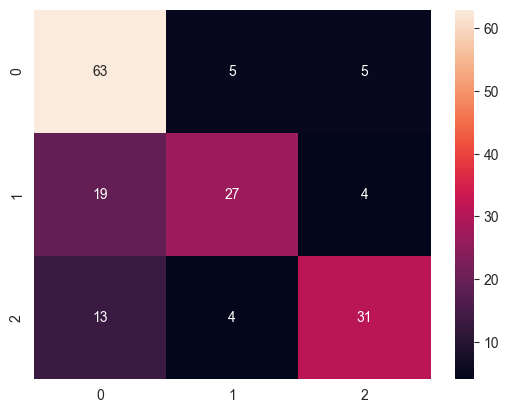

In [57]:
cm = evaluate_categorical_model(ft_model, validation_data_dir, validation_labels)


In [38]:
def pipe31(image_path, model):
    urllib.request.urlretrieve(image_path, 'save.jpg')
    img = load_img('save.jpg', target_size=(256,256))
    x = img_to_array(img)
    x = x.reshape((1,)+x.shape)/255
    pred = model.predict(x)
    pred_labels = np.argmax(pred, axis=1)
    d = {0:'Front', 1:'Rear', 2:'Side'}
    for key in d.keys():
        if pred_labels[0] == key:
            print("Validating location of damage....Result:",d[key])
    print("Severity assessment complete.")

In [39]:
def view_images(img_dir, img_list):
    for img in img_list:
        clear_output()
        display(Image(img_dir+img))
        num = raw_input("c to continue, q to quit")
        if num == 'c':
            pass
        else:
            return 'Finished for now.'

Best Model:
epoch: 45 , val_accuracy: 0.7265625 , val_loss: 0.6874711513519287


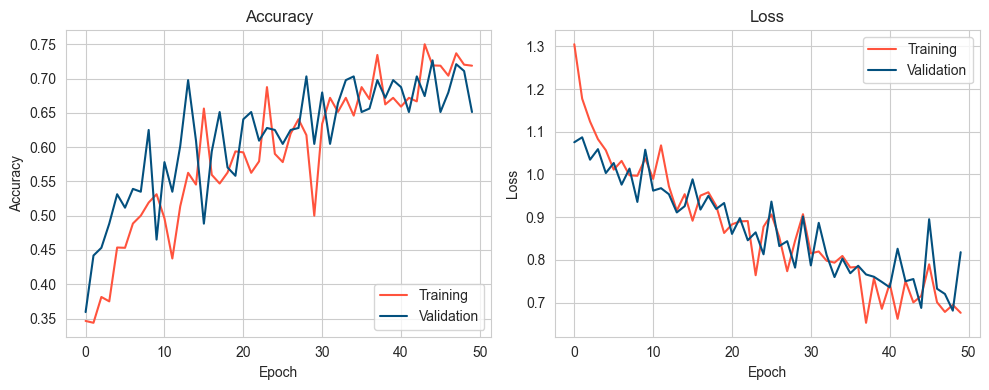

In [40]:
plot_metrics(ft_history)


Best Model:
epoch: 45 , val_accuracy: 0.7265625 , val_loss: 0.6874711513519287


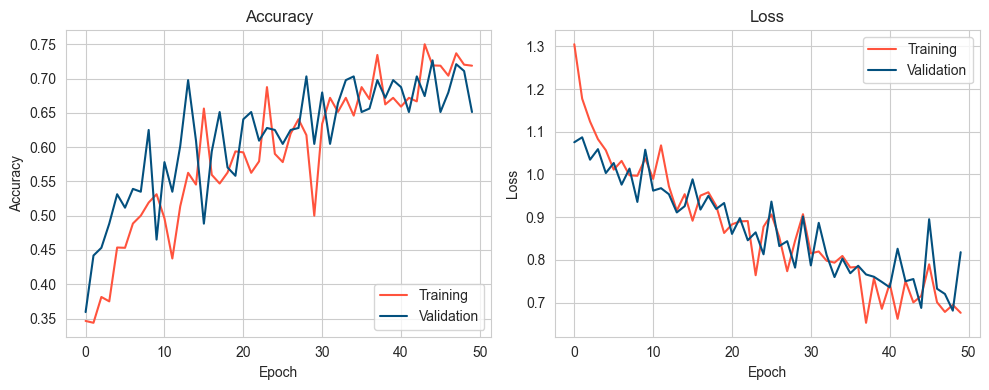

In [41]:
plot_metrics(ft_history)


Found 171 images belonging to 3 classes.


c:\Users\pbans\OneDrive\Desktop\CD2\.conda\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 487ms/step

              precision    recall  f1-score   support

           0       0.66      0.86      0.75        73
           1       0.75      0.54      0.63        50
           2       0.78      0.65      0.70        48

    accuracy                           0.71       171
   macro avg       0.73      0.68      0.69       171
weighted avg       0.72      0.71      0.70       171




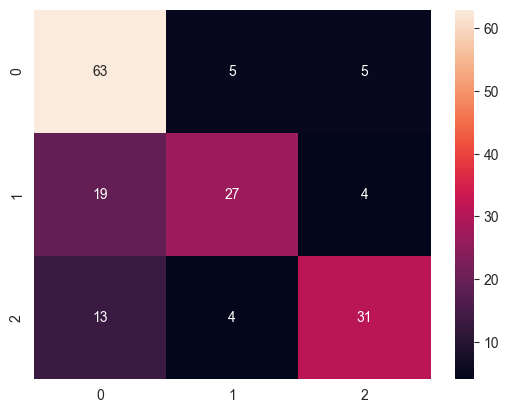

In [42]:
evaluate_categorical_model(ft_model, validation_data_dir, validation_labels)


In [43]:
heatmap_labels = ['Front', 'Rear', 'Side']


Found 171 images belonging to 3 classes.


c:\Users\pbans\OneDrive\Desktop\CD2\.conda\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 500ms/step

              precision    recall  f1-score   support

           0       0.66      0.86      0.75        73
           1       0.75      0.54      0.63        50
           2       0.78      0.65      0.70        48

    accuracy                           0.71       171
   macro avg       0.73      0.68      0.69       171
weighted avg       0.72      0.71      0.70       171




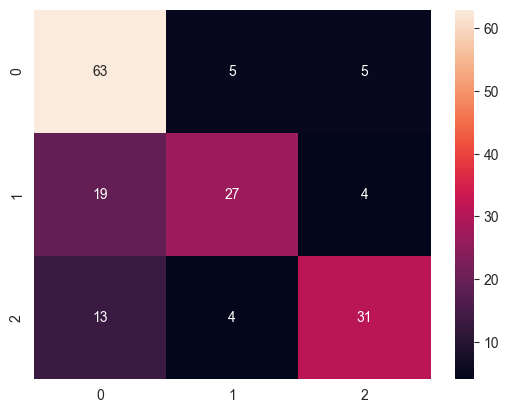

In [45]:
cm = evaluate_categorical_model(ft_model, validation_data_dir, validation_labels)


In [60]:
def evaluate_categorical_model(model, directory, labels):
    datagen = ImageDataGenerator(rescale=1./255)  

    generator = datagen.flow_from_directory(directory,
                                target_size=(img_height, img_width),
                                batch_size=16,
                                class_mode='categorical',
                                shuffle=False)

    # Predict classes
    predictions = model.predict(generator, steps=len(generator))
    pred_labels = np.argmax(predictions, axis=1)

    # Print classification report
    print('\n')
    print(classification_report(labels, pred_labels))
    print('\n')

    # Compute and return confusion matrix
    cm = confusion_matrix(labels, pred_labels)
    return cm


Found 171 images belonging to 3 classes.


c:\Users\pbans\OneDrive\Desktop\CD2\.conda\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 914ms/step


              precision    recall  f1-score   support

           0       0.66      0.86      0.75        73
           1       0.75      0.54      0.63        50
           2       0.78      0.65      0.70        48

    accuracy                           0.71       171
   macro avg       0.73      0.68      0.69       171
weighted avg       0.72      0.71      0.70       171





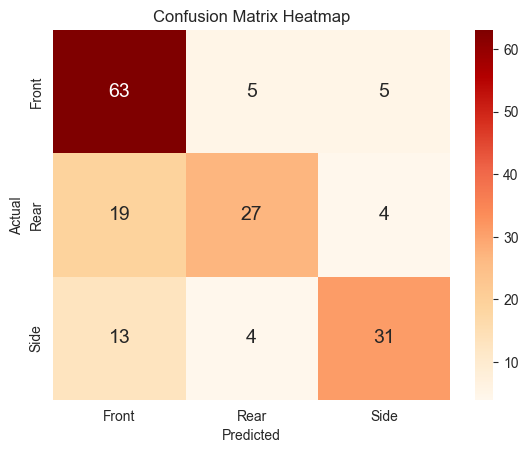

In [61]:
heatmap_labels = ['Front', 'Rear', 'Side']
cm = evaluate_categorical_model(ft_model, validation_data_dir, validation_labels)

sns.heatmap(cm, annot=True, annot_kws={"size": 14}, fmt='g', cmap='OrRd',
            xticklabels=heatmap_labels, yticklabels=heatmap_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()


In [62]:
def get_edge_cases(model, directory, exp_result, false_result):
    img_list = os.listdir(directory)
    edge_list = []
    for name in img_list:
        img = load_img(directory+name, target_size=(256, 256)) # this is a PIL image 
        x = img_to_array(img) # this is a Numpy array with shape (3, 256, 256)
        x = x.reshape((1,) + x.shape)/255 # this is a Numpy array with shape (1, 3, 256, 256)
        pred = model.predict(x)
        pred_label = np.argmax(pred, axis=1)
        if pred_label[0] == false_result:
            edge_list.append(name)
    return edge_list

In [63]:
def pipe31(image_path, model):
    urllib.request.urlretrieve(image_path, 'save.jpg')
    img = load_img('save.jpg', target_size=(256,256))
    x = img_to_array(img)
    x = x.reshape((1,)+x.shape)/255
    pred = model.predict(x)
    pred_labels = np.argmax(pred, axis=1)
    d = {0:'Front', 1:'Rear', 2:'Side'}
    for key in d.keys():
        if pred_labels[0] == key:
            print("Validating location of damage....Result:",d[key])
    print("Severity assessment complete.")

In [ ]:
import requests
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np

def pipe31(image_url, model):
    # Download the image
    response = requests.get(image_url, stream=True)
    
    if response.status_code == 200 and 'image' in response.headers['Content-Type']:
        with open('save.jpg', 'wb') as f:
            f.write(response.content)
        
        # Load and preprocess the image
        img = load_img('save.jpg', target_size=(256, 256))
        x = img_to_array(img)
        x = x.reshape((1,) + x.shape) / 255.0
        
        # Make a prediction
        pred = model.predict(x)
        pred_labels = np.argmax(pred, axis=1)
        
        # Map prediction to class
        d = {0: 'minor', 1: 'moderate', 2: 'severe'}
        print("Validating location of damage....Result:", d.get(pred_labels[0], 'Unknown'))
        print("Severity assessment complete.")
    else:
        print("Error: Could not download or identify the image. Please check the URL.")

# Usage
pipe32('https://drndata.com/wp-content/uploads/2016/03/car.jpg', ft_d3_model)

In [64]:
Image('https://www.copartdirect.com/content/2007-kia-rio-front-end-damage.jpg')

In [65]:
import requests
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np

def pipe31(image_url, model):
    # Download the image
    response = requests.get(image_url, stream=True)
    
    if response.status_code == 200 and 'image' in response.headers['Content-Type']:
        with open('save.jpg', 'wb') as f:
            f.write(response.content)
        
        # Load and preprocess the image
        img = load_img('save.jpg', target_size=(256, 256))
        x = img_to_array(img)
        x = x.reshape((1,) + x.shape) / 255.0
        
        # Make a prediction
        pred = model.predict(x)
        pred_labels = np.argmax(pred, axis=1)
        
        # Map prediction to class
        d = {0: 'Front', 1: 'Rear', 2: 'Side'}
        print("Validating location of damage....Result:", d.get(pred_labels[0], 'Unknown'))
        print("Severity assessment complete.")
    else:
        print("Error: Could not download or identify the image. Please check the URL.")

# Usage
pipe31('https://drndata.com/wp-content/uploads/2016/03/car.jpg', ft_model)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step
Validating location of damage....Result: Rear
Severity assessment complete.


In [71]:
ft_model.summary()

Model: "functional_37"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 256, 256, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 256, 256, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 128, 128, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 32, 32, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 16, 16, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_8 (Sequential)       │ (None, 3)              │     8,389,635 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,573,384 (147.15 MB)

 Trainable params: 15,469,059 (59.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

 Optimizer params: 15,469,061 (59.01 MB)